# HAR TFM

In [1]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns

import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics


ruta_archivo_csv = "../../Procesamiento Datos/Dataset/HAR_TFM.csv"

df = pd.read_csv(ruta_archivo_csv)
print(df)


              Ax        Ay        Az       Gx        Gy        Gz          Mx  \
0       0.028037  0.272983  0.938547 -0.85745  1.530512 -1.285625   16.856251   
1       0.036297 -1.118226 -0.264005 -0.61710  0.379362 -0.267025  362.943756   
2       0.032427  0.145508  1.354897 -1.07635 -1.441825  0.696025    0.356250   
3       0.370183  0.204207  0.954832 -0.37954 -0.559665 -0.238312  -25.068750   
4       1.329001 -0.985352  0.107682  1.72095 -1.653575 -1.253725  -39.600002   
...          ...       ...       ...      ...       ...       ...         ...   
365995  0.177876  0.465430  0.859490 -0.09094  0.068109  0.005574  -19.800001   
365996  0.351190 -0.832287 -0.448884 -0.00990 -0.000825  0.009762   32.812500   
365997  1.014918 -0.141639  0.255638  0.01265  0.007700  0.000137    3.187500   
365998  1.009626 -0.294183 -0.150097  0.02640  0.024750  0.030938   36.000000   
365999  0.230048 -0.802216 -0.552589 -0.00770 -0.023100 -0.003025  -15.356251   

               My         M

# Modelo de red neuronal

In [2]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','AyMx','AzMx','Gz']

In [3]:
#Para ver la mayor corelación
#features = ['AyGx', 'AyGy', 'Myz', 'Ayz', 'Mxy', 'Gzy', 'AyMz', 'MyGy', 'AyMy', 'MyGx', 'Mxz', 'AxMy', 'Az', 'Mx', 'AxGx', 'Mz', 'AxGy', 'MxGx', 'AzGx']
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 366000
Número de columnas: 22


In [4]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(256, input_shape=(1, X_train.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(6, activation='softmax'))
#--------------------------------------------
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))
model.add(LSTM(128))
#model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
#--------------------------------------------
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(LSTM(128))
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense
#model.add(Dense(6, activation='softmax'))
#------------------------------------------------
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la primera capa LSTM
#model.add(LSTM(128))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la segunda capa LSTM
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la otra capa Dense adicional
#model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2026-08-13 16:53:04.163160: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 16:53:04.166556: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 16:53:04.209907: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-13 16:53:04.211334: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-13 16:53:05.086527: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

Epoch 1/20
4575/4575 [==============================] - 45s 9ms/step - loss: 0.6704 - accuracy: 0.7589 - val_loss: 0.5399 - val_accuracy: 0.8075
Epoch 2/20
4575/4575 [==============================] - 41s 9ms/step - loss: 0.4904 - accuracy: 0.8269 - val_loss: 0.4561 - val_accuracy: 0.8417
Epoch 3/20
4575/4575 [==============================] - 40s 9ms/step - loss: 0.4312 - accuracy: 0.8476 - val_loss: 0.4333 - val_accuracy: 0.8444
Epoch 4/20
4575/4575 [==============================] - 39s 9ms/step - loss: 0.3954 - accuracy: 0.8591 - val_loss: 0.3883 - val_accuracy: 0.8623
Epoch 5/20
4575/4575 [==============================] - 40s 9ms/step - loss: 0.3687 - accuracy: 0.8686 - val_loss: 0.3582 - val_accuracy: 0.8719
Epoch 6/20
4575/4575 [==============================] - 39s 9ms/step - loss: 0.3469 - accuracy: 0.8761 - val_loss: 0.3458 - val_accuracy: 0.8771
Epoch 7/20
4575/4575 [==============================] - 40s 9ms/step - loss: 0.3328 - accuracy: 0.8806 - val_loss: 0.3443 - val_ac

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2288/2288 [==============================] - 9s 4ms/step
Accuracy: 0.9045901639344263
Precision: 0.9067612752296678
Recall: 0.9045901639344263
F1 Score: 0.9053977423159234


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

   1/2288 [..............................] - ETA: 53s

2288/2288 [==============================] - 8s 4ms/step


/home/rclozano/TFM_HAR/tf_env.venv/lib/python3.8/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Label: 1, Caminar
Accuracy: 0.9412568306010929
Precision: 0.8222583265637693
Recall: 0.8273663560568907
F1 Score: 0.8248044328552804

Label: 2, Metro
Accuracy: 0.9770765027322404
Precision: 0.947300439163007
Recall: 0.9116598988978205
F1 Score: 0.9291385135135135

Label: 3, Bus
Accuracy: 0.9810245901639344
Precision: 0.9581469918150367
Recall: 0.9270901371652515
F1 Score: 0.9423627536412299

Label: 4, Conducir coche
Accuracy: 0.9923360655737705
Precision: 0.9765002439421044
Recall: 0.9778519664522433
F1 Score: 0.9771756377395338

Label: 5, Subir o bajar escaleras
Accuracy: 0.9357650273224044
Precision: 0.7859871638141809
Recall: 0.8440269117164424
F1 Score: 0.8139737300205729

Label: 6, Estar detenido
Accuracy: 0.9817213114754099
Precision: 0.9503322259136212
Recall: 0.9392546379904777
F1 Score: 0.9447609611097348



## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

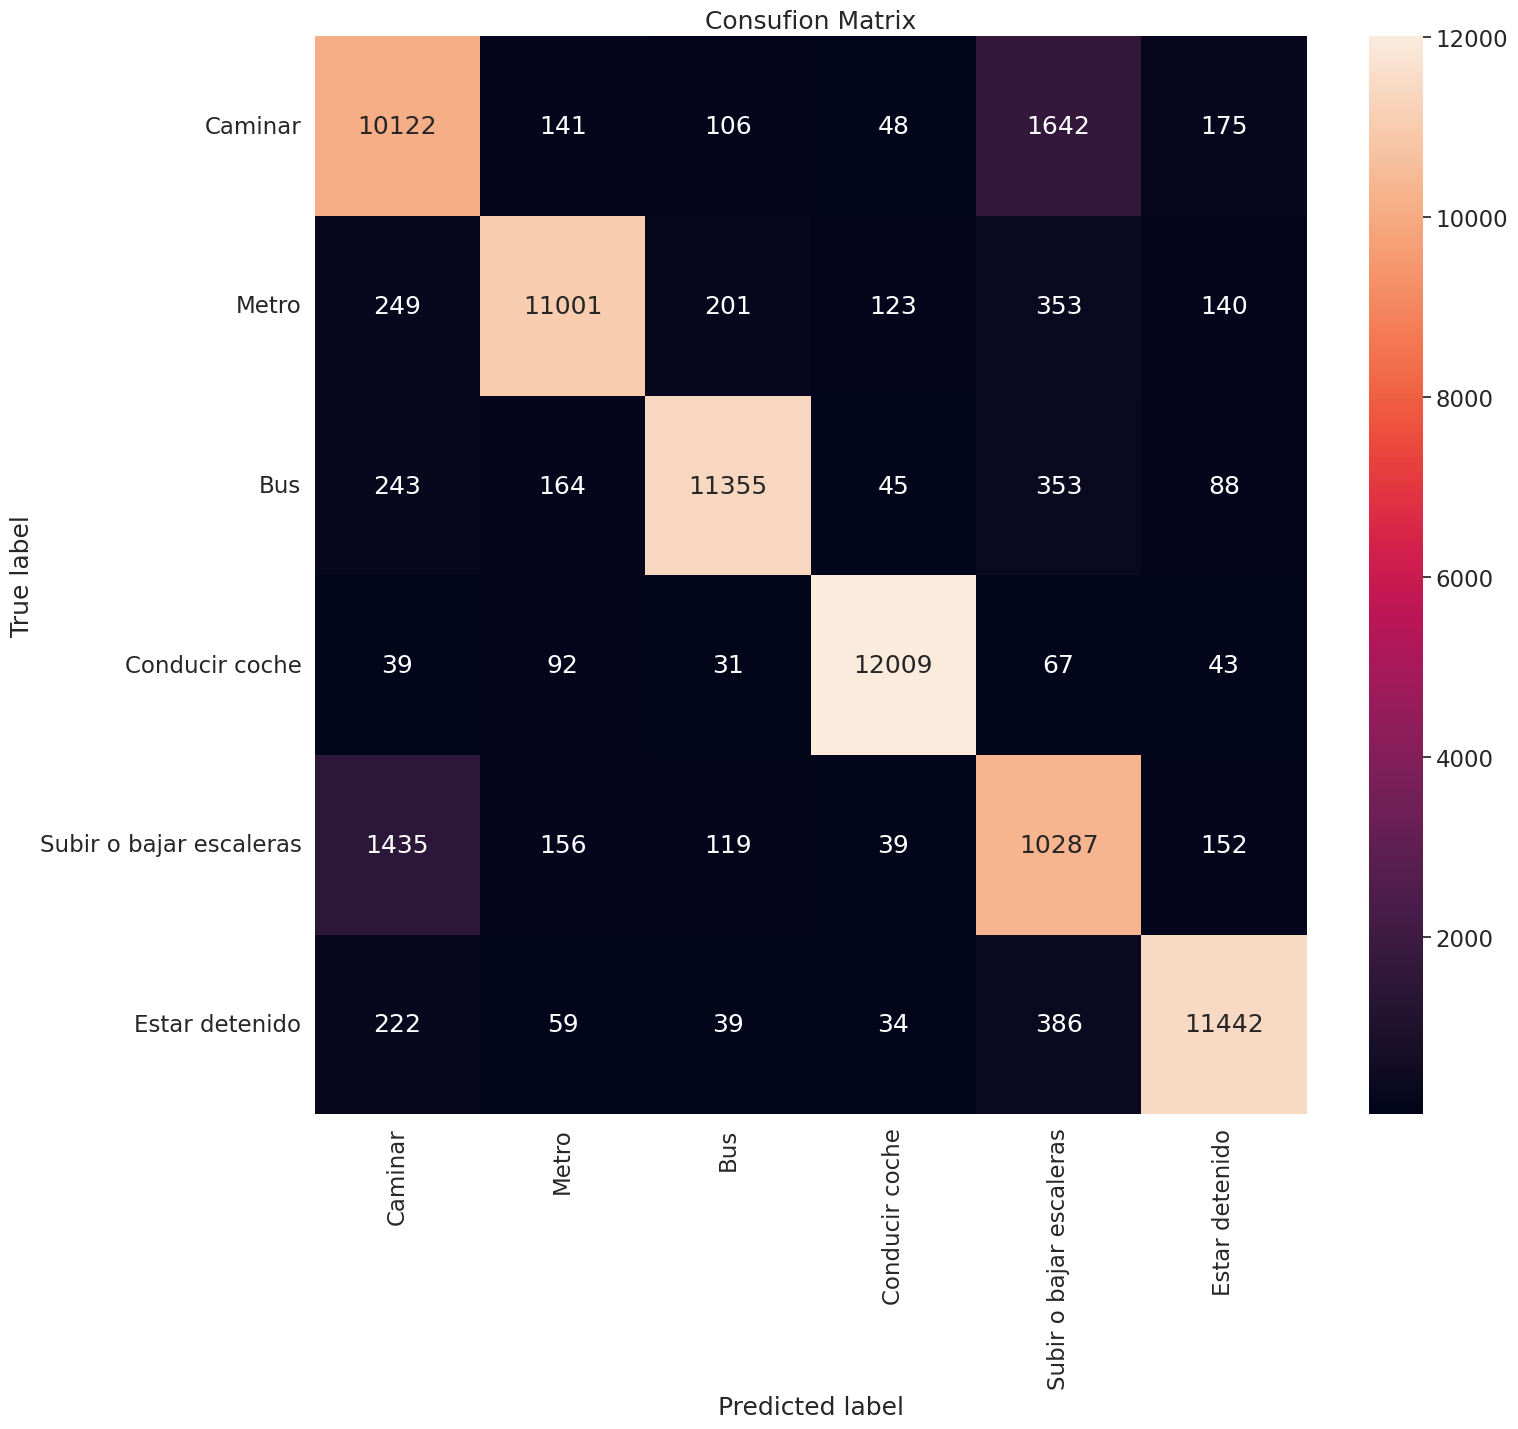

In [7]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [8]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 12234, Actividad: Caminar
Valor: 1, Cantidad: 12067, Actividad: Metro
Valor: 2, Cantidad: 12248, Actividad: Bus
Valor: 3, Cantidad: 12281, Actividad: Conducir coche
Valor: 4, Cantidad: 12188, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 12182, Actividad: Estar detenido


In [9]:
ruta2_archivo_csv = "../../Datos/sensor_data.csv"

df2 = pd.read_csv(ruta2_archivo_csv)
print(df2)

         Timestamp      AccX      AccY      AccZ     GyroX     GyroY  \
0    1706746399642  0.000000  0.000000  0.000000 -0.000229 -0.000764   
1    1706746399844  0.002075  0.000598  0.004781 -0.000305 -0.000534   
2    1706746400046 -0.002117 -0.001160  0.002576 -0.000305 -0.000534   
3    1706746400249 -0.001162  0.002592  0.001495 -0.000382 -0.000382   
4    1706746400451 -0.003550 -0.001198  0.001524 -0.000229 -0.000305   
..             ...       ...       ...       ...       ...       ...   
564  1706746513744 -0.000282 -0.001125 -0.002080 -0.000076  0.000000   
565  1706746513945  0.002758 -0.003382 -0.001465  0.000076 -0.000076   
566  1706746514149  0.000905  0.000575  0.001459  0.000153  0.000076   
567  1706746514351 -0.000187 -0.001075 -0.003736 -0.000076  0.000305   
568  1706746514554  0.002216  0.000832 -0.002038 -0.000076 -0.000076   

        GyroZ        MagX       MagY       MagZ  
0    0.000840  107.231255 -95.137505  29.531252  
1    0.000993  107.418755 -94.95000

In [10]:
columnas_deseadas = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ", "MagX", "MagY", "MagZ", "Timestamp"]  # Cambia los nombres de las columnas según tus necesidades
df2 = df2.reindex(columns=columnas_deseadas)
print(df2)

         AccX      AccY      AccZ     GyroX     GyroY     GyroZ        MagX  \
0    0.000000  0.000000  0.000000 -0.000229 -0.000764  0.000840  107.231255   
1    0.002075  0.000598  0.004781 -0.000305 -0.000534  0.000993  107.418755   
2   -0.002117 -0.001160  0.002576 -0.000305 -0.000534  0.000840  107.568756   
3   -0.001162  0.002592  0.001495 -0.000382 -0.000382  0.000840  107.737500   
4   -0.003550 -0.001198  0.001524 -0.000229 -0.000305  0.000993  107.662506   
..        ...       ...       ...       ...       ...       ...         ...   
564 -0.000282 -0.001125 -0.002080 -0.000076  0.000000 -0.001069  107.287506   
565  0.002758 -0.003382 -0.001465  0.000076 -0.000076 -0.000611  107.231255   
566  0.000905  0.000575  0.001459  0.000153  0.000076 -0.000382  107.100006   
567 -0.000187 -0.001075 -0.003736 -0.000076  0.000305 -0.001069  107.193756   
568  0.002216  0.000832 -0.002038 -0.000076 -0.000076 -0.001069  107.287506   

          MagY       MagZ      Timestamp  
0   -95.

In [11]:
# Nuevos nombres de columnas
nuevos_nombres = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "timestamp"]  # Cambia los nombres de las columnas según tus necesidades

# Asignar los nuevos nombres de columnas
df2.columns = nuevos_nombres

In [12]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df2["AxMy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['My']))
df2["AxGy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gy']))
df2["Ayz"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Az']))
df2["AxGx"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gx']))
df2["AxGy"] = np.sqrt(np.square(df2['Ax']) + np.square(df2['Gy']))
df2["AyGx"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Gx']))
df2["AyGy"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Gy']))
df2["AyMy"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['My']))
df2["AyMx"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Mx']))
df2["AyMz"] = np.sqrt(np.square(df2['Ay']) + np.square(df2['Mz']))
df2["AzGx"] = np.sqrt(np.square(df2['Az']) + np.square(df2['Gx']))
df2["AzMx"] = np.sqrt(np.square(df2['Az']) + np.square(df2['Mx']))
df2["Gzy"] = np.sqrt(np.square(df2['Gz']) + np.square(df2['Gy']) )
df2["MxGy"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Gy']) )
df2["MxGx"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Gx']) )
df2["MyGy"] = np.sqrt(np.square(df2['My']) + np.square(df2['Gy']) )
df2["MyGx"] = np.sqrt(np.square(df2['My']) + np.square(df2['Gx']) )
df2["Myz"] = np.sqrt(np.square(df2['My']) + np.square(df2['Mz']))
df2["Mxz"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['Mz']))
df2["Mxy"] = np.sqrt(np.square(df2['Mx']) + np.square(df2['My']))

In [13]:
# Supongamos que tienes un DataFrame llamado 'nuevos_datos' con las mismas características que 'df'
nuevos_X_orig = df2[features]

# Ajustar forma de los datos para LSTM
nuevos_X = nuevos_X_orig.to_numpy()
nuevos_X = nuevos_X.astype(float)
nuevos_X = np.reshape(nuevos_X, (nuevos_X.shape[0], 1, nuevos_X.shape[1]))

# Realizar predicciones
predicciones = model.predict(nuevos_X)

# Si deseas obtener la etiqueta predicha en lugar de la codificación one-hot, puedes usar argmax
etiquetas_predichas = np.argmax(predicciones, axis=1)

# Decodificar las etiquetas (si es necesario)
#etiquetas_predichas_decodificadas = label_encoder.inverse_transform(etiquetas_predichas)

# Imprimir o utilizar las predicciones según tus necesidades
print(etiquetas_predichas)


18/18 [==============================] - 0s 3ms/step
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 